# Multimodal Housing Price Prediction — CNN + Tabular Fusion

**Objective:** predict a house's sale price using two very different kinds of input at once, the
usual structured columns (bedrooms, bathrooms, square footage, zip code) *and* photos of the
house (bedroom, bathroom, kitchen, front exterior). The structured data tells you the "spec sheet,"
the photos tell you things a spec sheet can't (finish quality, staging, curb appeal). The bet with
multimodal fusion is that combining both beats either one alone.

**Dataset:** [Houses Dataset (Ahmed & Moataz, 2016)](https://github.com/emanhamed/Houses-dataset)
535 houses scraped from real estate listings across California, Texas, New York and Connecticut.
Each house has 4 photos (bedroom / bathroom / kitchen / frontal) plus a text file with bedrooms,
bathrooms, area, zip code, and price. This is the standard public benchmark for this exact
image+tabular regression problem, which is why we're using it instead of stitching together two
unrelated datasets.

**What this notebook does, in order:**
1. Load and explore the tabular data
2. Build a single "montage" image per house from the 4 room photos
3. Preprocess both modalities (scaling, zip-code binning, image normalization)
4. Train three models; tabular-only, image-only, and a fused CNN+MLP, so we can actually see
   whether fusion helps, rather than just assuming it does
5. Evaluate all three with MAE and RMSE
6. Visualize training curves and prediction quality


In [ ]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline

# Fixing seeds so re-runs don't give wildly different numbers
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


I0000 00:00:1783547762.917766    5113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783547762.967355    5113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783547764.627414    5113 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


## 1. Loading the tabular data

`HousesInfo.txt` is whitespace-separated with no header: bedrooms, bathrooms, area (sqft),
zip code, price. Row order matches the image filenames, row 1 is house `1`, so `1_bedroom.jpg`,
`1_bathroom.jpg` etc. belong to it. That's a fragile assumption to hardcode, but it's how the
dataset is structured, so we lean on it.

In [ ]:
DATA_DIR = os.path.join("..", "data", "Houses Dataset")

COLS = ["bedrooms", "bathrooms", "area", "zipcode", "price"]
df = pd.read_csv(os.path.join(DATA_DIR, "HousesInfo.txt"), sep=" ", header=None, names=COLS)

# filenames are 1-indexed and follow row order, this is the assumption the whole
# image-loading step depends on, so it earns its own explicit column instead of
# being inferred implicitly from the row index later.
df["house_id"] = np.arange(1, len(df) + 1)

print(f"{len(df)} houses loaded")
df.head()


535 houses loaded


,bedrooms,bathrooms,area,zipcode,price,house_id
0,4,4.0,4053,85255,869500,1
1,4,3.0,3343,36372,865200,2
2,3,4.0,3923,85266,889000,3
3,5,5.0,4022,85262,910000,4
4,3,4.0,4116,85266,971226,5


In [3]:
df.describe()


,bedrooms,bathrooms,area,zipcode,price,house_id
count,535.000000,535.000000,535.000000,535.000000,5.350000e+02,535.000000
mean,3.377570,2.664953,2364.904673,90937.768224,5.893628e+05,268.000000
std,1.160952,0.995077,1224.556982,7141.857452,5.090261e+05,154.585467
min,1.000000,1.000000,701.000000,36372.000000,2.200000e+04,1.000000
25%,3.000000,2.000000,1440.000000,92276.000000,2.492000e+05,134.500000
50%,3.000000,2.500000,2078.000000,92880.000000,5.290000e+05,268.000000
75%,4.000000,3.000000,3067.500000,93510.000000,7.285000e+05,401.500000
max,10.000000,7.000000,9583.000000,98021.000000,5.858000e+06,535.000000


A quick sanity check before we go further: are there any missing images? The dataset page
doesn't guarantee every house has all 4 photos, and a silent `FileNotFoundError` 400 images deep
into a loop is not a fun debugging session.

In [4]:
missing = []
for hid in df["house_id"]:
    for kind in ["bedroom", "bathroom", "kitchen", "frontal"]:
        path = os.path.join(DATA_DIR, f"{hid}_{kind}.jpg")
        if not os.path.exists(path):
            missing.append(path)

print(f"missing images: {len(missing)}")
if missing:
    print(missing[:10])


missing images: 0


### Exploratory look at price

Real estate prices are almost always right-skewed, a handful of expensive houses drag the mean
up above the median. Worth confirming before we pick a loss function, because training directly
on raw price would let those outliers dominate the gradient.

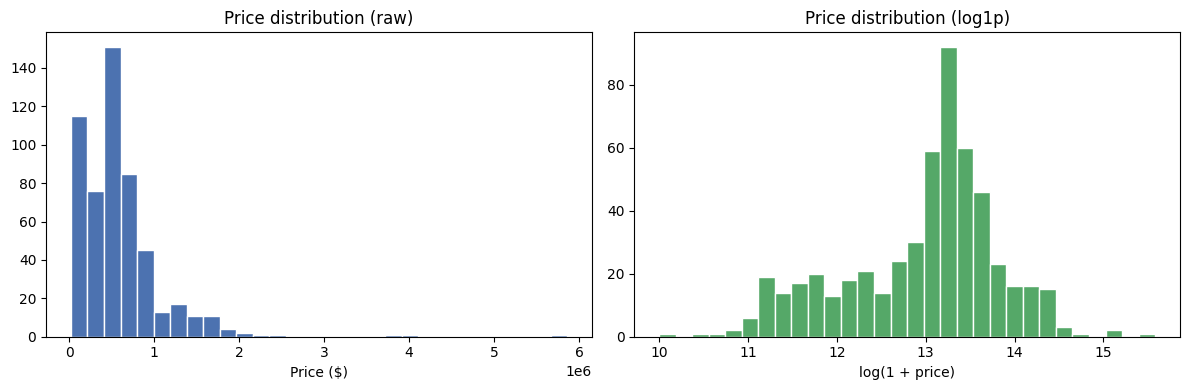

skew (raw price):      3.73
skew (log1p price):    -0.58


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Price distribution (raw)")
axes[0].set_xlabel("Price ($)")

axes[1].hist(np.log1p(df["price"]), bins=30, color="#55A868", edgecolor="white")
axes[1].set_title("Price distribution (log1p)")
axes[1].set_xlabel("log(1 + price)")

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "price_distribution.png"), dpi=120)
plt.show()

print(f"skew (raw price):      {df['price'].skew():.2f}")
print(f"skew (log1p price):    {np.log1p(df['price']).skew():.2f}")


Raw price is heavily right-skewed, log-transforming flattens it out a lot. We'll train
on `log1p(price)` and undo the transform (`expm1`) when we report MAE/RMSE, so the metrics we
report at the end are in actual dollars, not log-dollars.

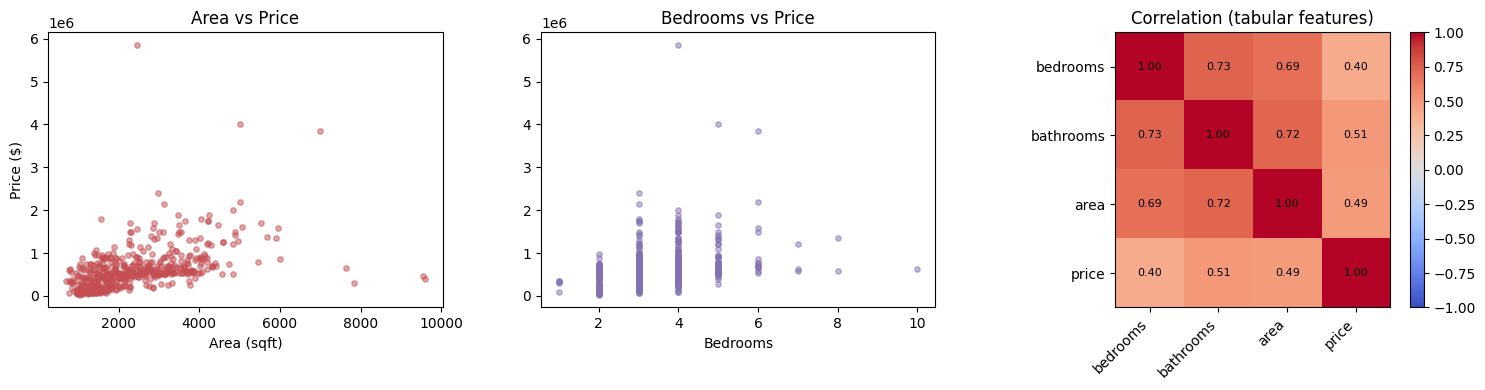

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df["area"], df["price"], alpha=0.5, s=15, color="#C44E52")
axes[0].set_xlabel("Area (sqft)")
axes[0].set_ylabel("Price ($)")
axes[0].set_title("Area vs Price")

axes[1].scatter(df["bedrooms"], df["price"], alpha=0.5, s=15, color="#8172B2")
axes[1].set_xlabel("Bedrooms")
axes[1].set_title("Bedrooms vs Price")

corr = df[["bedrooms", "bathrooms", "area", "price"]].corr()
im = axes[2].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_xticks(range(len(corr.columns)))
axes[2].set_yticks(range(len(corr.columns)))
axes[2].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[2].set_yticklabels(corr.columns)
axes[2].set_title("Correlation (tabular features)")
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        axes[2].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()


Area correlates with price the most out of the three continuous features, which is exactly
what you'd expect and a decent sign the data isn't garbage. Zip code isn't in this heatmap because
it's categorical, we'll one-hot encode it in the preprocessing step.

## 2. Building the image input: one montage per house

Each house comes with 4 separate photos. Feeding 4 images per house into 4 separate CNN towers
would work but quadruples the parameter count for a dataset with only 535 rows. The standard trick for this dataset (and the one we use here) is to **tile the 4
photos into a single 2x2 montage image** and run *one* CNN over that. It's a cheap way to let the
network see all 4 rooms at once without exploding model size.

In [7]:
TILE = 32  # each room photo gets resized down to TILE x TILE before tiling
MONTAGE_SIZE = TILE * 2  # final montage is 2x2 tiles

def build_montage(house_id):
    quadrants = []
    for kind in ["bedroom", "bathroom", "kitchen", "frontal"]:
        path = os.path.join(DATA_DIR, f"{house_id}_{kind}.jpg")
        img = Image.open(path).convert("RGB").resize((TILE, TILE))
        quadrants.append(np.array(img, dtype=np.uint8))

    top = np.hstack([quadrants[0], quadrants[1]])      # bedroom | bathroom
    bottom = np.hstack([quadrants[2], quadrants[3]])   # kitchen | frontal
    montage = np.vstack([top, bottom])
    return montage


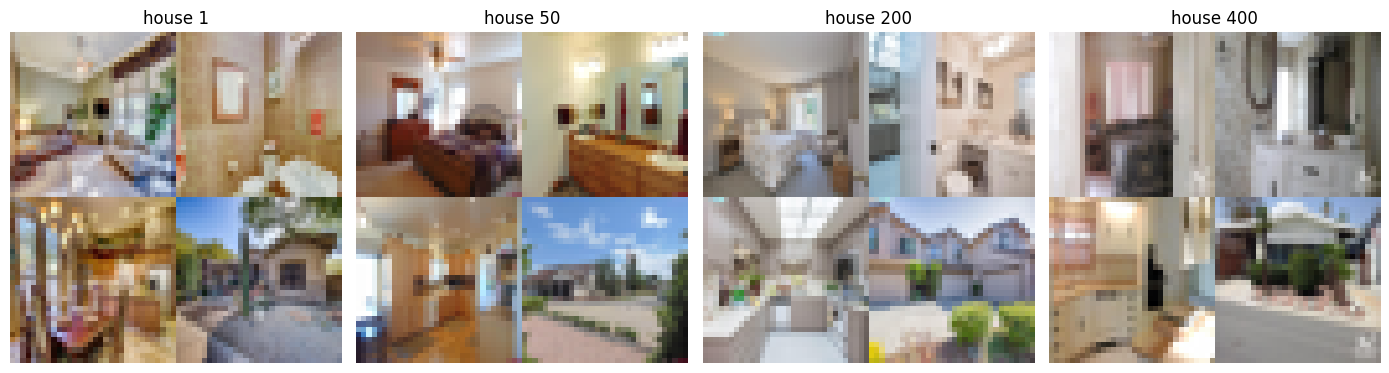

In [ ]:
# preview a few montages before committing to building all 535 cheap way to catch a
# transposed/rotated image bug before it's baked into the whole dataset
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, hid in zip(axes, [1, 50, 200, 400]):
    ax.imshow(build_montage(hid))
    ax.set_title(f"house {hid}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [9]:
t0 = time.time()
images = np.zeros((len(df), MONTAGE_SIZE, MONTAGE_SIZE, 3), dtype=np.float32)
for i, hid in enumerate(df["house_id"]):
    images[i] = build_montage(hid).astype(np.float32) / 255.0  # scale to [0, 1] for the CNN

print(f"built {len(df)} montages in {time.time() - t0:.1f}s")
print("images array shape:", images.shape)


built 535 montages in 13.0s
images array shape: (535, 64, 64, 3)


## 3. Preprocessing the tabular side

Two things need handling here:
- **Continuous features** (bedrooms, bathrooms, area) get min-max scaled so they're on a
  comparable range to everything else feeding the network.
- **Zip code** is nominally numeric but it's really a category label, treating `85255` as
  "bigger than" `36372` would just confuse the model. One-hot encoding is the right move, but
  raw one-hot on every unique zip would create more columns than we have training rows for some
  of them. So we bucket anything with fewer than 20 houses into a single "other" category first.

In [10]:
zip_counts = df["zipcode"].value_counts()
rare_zips = zip_counts[zip_counts < 20].index
df["zipcode_grouped"] = df["zipcode"].where(~df["zipcode"].isin(rare_zips), other=-1).astype(str)

print("zip codes before grouping:", df["zipcode"].nunique())
print("zip buckets after grouping:", df["zipcode_grouped"].nunique())
df["zipcode_grouped"].value_counts()


zip codes before grouping: 49
zip buckets after grouping: 9


zipcode_grouped
-1       151
92276    100
93510     60
93446     54
92880     49
94501     41
91901     32
92677     26
94531     22
Name: count, dtype: int64

In [11]:
cont_scaler = MinMaxScaler()
cont_feats = cont_scaler.fit_transform(df[["bedrooms", "bathrooms", "area"]])

zip_dummies = pd.get_dummies(df["zipcode_grouped"], prefix="zip").astype(np.float32)

tabular = np.hstack([cont_feats, zip_dummies.values]).astype(np.float32)
print("tabular feature matrix shape:", tabular.shape)


tabular feature matrix shape: (535, 12)


## 4. Train/test split and target scaling

Splitting 80/20. The target is `log1p(price)`, which as we saw above still sits around 12-14,
way outside the range a freshly initialized dense layer naturally outputs. Standardizing it
(zero mean, unit variance) means the network isn't wasting its first several epochs just walking
the output bias up to the right ballpark before it can start learning anything useful.

In [ ]:
y_log = np.log1p(df["price"].values.astype(np.float32))

idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.2, random_state=SEED)

X_img_train, X_img_test = images[idx_train], images[idx_test]
X_tab_train, X_tab_test = tabular[idx_train], tabular[idx_test]
y_train_log, y_test_log = y_log[idx_train], y_log[idx_test]
price_train, price_test = df["price"].values[idx_train], df["price"].values[idx_test]

y_mean, y_std = y_train_log.mean(), y_train_log.std()
y_train_z = (y_train_log - y_mean) / y_std
# note: we deliberately do NOT standardize y_test using its own mean/std, would leak
# test-set statistics into preprocessing. We reuse the train mean/std for inverting predictions.

print(f"train: {len(idx_train)} houses, test: {len(idx_test)} houses")


train: 428 houses, test: 107 houses


## 5. Model architecture

Three models, built from the same two branch functions so the comparison is fair:

- **Tabular-only baseline**: small MLP on the structured features alone.
- **Image-only baseline**: small CNN on the montage image alone.
- **Fusion model**: both branches run in parallel, their output feature vectors get
  concatenated, and a couple more dense layers turn the combined vector into a price prediction.

The CNN is deliberately shallow (3 conv blocks). With 535 training examples, a deep network
would just memorize noise, more capacity isn't free when data is this limited.

In [ ]:
def make_cnn_branch(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(16, activation="relu")(x)
    x = layers.Dropout(0.3)(x)  # 535 samples overfits fast without this
    return inp, x


def make_tabular_branch(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(16, activation="relu")(inp)
    x = layers.Dense(8, activation="relu")(x)
    return inp, x


def make_early_stopping():
    # patience=15 because val_loss on a dataset this small is noisy, stopping at the
    # first uptick would cut training short way too aggressively
    return keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor="val_loss")


### Why train three models instead of just the fusion model?

Because "we combined images and tabular data" doesn't tell you whether the images actually
*helped*. Without the two single-modality baselines, a mediocre fusion result is unexplainable
you can't tell if fusion is underperforming because the image branch is dragging it down, or
because it's basically ignoring the images anyway. Training all three costs a few extra minutes
of CPU time and buys a much more honest evaluation.

In [14]:
histories = {}
models = {}


In [15]:
# --- Tabular-only baseline ---
tab_in, tab_feat = make_tabular_branch(tabular.shape[1])
x = layers.Dense(8, activation="relu")(tab_feat)
out = layers.Dense(1, activation="linear")(x)
tabular_model = keras.Model(tab_in, out, name="tabular_only")
tabular_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])

t0 = time.time()
histories["tabular_only"] = tabular_model.fit(
    X_tab_train, y_train_z,
    validation_split=0.15, epochs=150, batch_size=16,
    verbose=0, callbacks=[make_early_stopping()],
)
models["tabular_only"] = tabular_model
print(f"[tabular-only] {len(histories['tabular_only'].history['loss'])} epochs, {time.time() - t0:.1f}s")


[tabular-only] 150 epochs, 43.7s


In [16]:
# --- Image-only baseline ---
img_in, img_feat = make_cnn_branch(images.shape[1:])
x = layers.Dense(8, activation="relu")(img_feat)
out = layers.Dense(1, activation="linear")(x)
image_model = keras.Model(img_in, out, name="image_only")
image_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])

t0 = time.time()
histories["image_only"] = image_model.fit(
    X_img_train, y_train_z,
    validation_split=0.15, epochs=100, batch_size=16,
    verbose=0, callbacks=[make_early_stopping()],
)
models["image_only"] = image_model
print(f"[image-only] {len(histories['image_only'].history['loss'])} epochs, {time.time() - t0:.1f}s")


[image-only] 67 epochs, 88.1s


In [17]:
# --- Fusion model ---
img_in2, img_feat2 = make_cnn_branch(images.shape[1:])
tab_in2, tab_feat2 = make_tabular_branch(tabular.shape[1])
combined = layers.concatenate([img_feat2, tab_feat2])
x = layers.Dense(8, activation="relu")(combined)
out = layers.Dense(1, activation="linear")(x)
fusion_model = keras.Model([img_in2, tab_in2], out, name="fusion")
fusion_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])

t0 = time.time()
histories["fusion"] = fusion_model.fit(
    [X_img_train, X_tab_train], y_train_z,
    validation_split=0.15, epochs=100, batch_size=16,
    verbose=0, callbacks=[make_early_stopping()],
)
models["fusion"] = fusion_model
print(f"[fusion] {len(histories['fusion'].history['loss'])} epochs, {time.time() - t0:.1f}s")


[fusion] 48 epochs, 63.8s


## 6. Evaluation

Predictions come out in standardized-log space, so we have to invert both transforms in the
right order (`* std + mean`, then `expm1`) to get back to dollars before computing MAE/RMSE.
Getting this order wrong is a classic way to silently produce nonsense metrics.

In [18]:
def evaluate_model(model, X_test, price_test, y_mean, y_std, is_multi_input=False):
    preds_z = model.predict(X_test, verbose=0).flatten()
    preds_log = preds_z * y_std + y_mean
    preds_price = np.expm1(preds_log)

    mae = np.mean(np.abs(preds_price - price_test))
    rmse = np.sqrt(np.mean((preds_price - price_test) ** 2))
    return mae, rmse, preds_price


In [19]:
results = {}
predictions = {}

mae, rmse, preds = evaluate_model(models["tabular_only"], X_tab_test, price_test, y_mean, y_std)
results["Tabular-only"] = (mae, rmse)
predictions["Tabular-only"] = preds

mae, rmse, preds = evaluate_model(models["image_only"], X_img_test, price_test, y_mean, y_std)
results["Image-only"] = (mae, rmse)
predictions["Image-only"] = preds

mae, rmse, preds = evaluate_model(models["fusion"], [X_img_test, X_tab_test], price_test, y_mean, y_std)
results["Fusion (image + tabular)"] = (mae, rmse)
predictions["Fusion (image + tabular)"] = preds

results_df = pd.DataFrame(results, index=["MAE ($)", "RMSE ($)"]).T
results_df["MAE ($)"] = results_df["MAE ($)"].round(0)
results_df["RMSE ($)"] = results_df["RMSE ($)"].round(0)
results_df


,MAE ($),RMSE ($)
Tabular-only,149683.0,228619.0
Image-only,272664.0,388596.0
Fusion (image + tabular),180482.0,261171.0


## 7. Visualizations

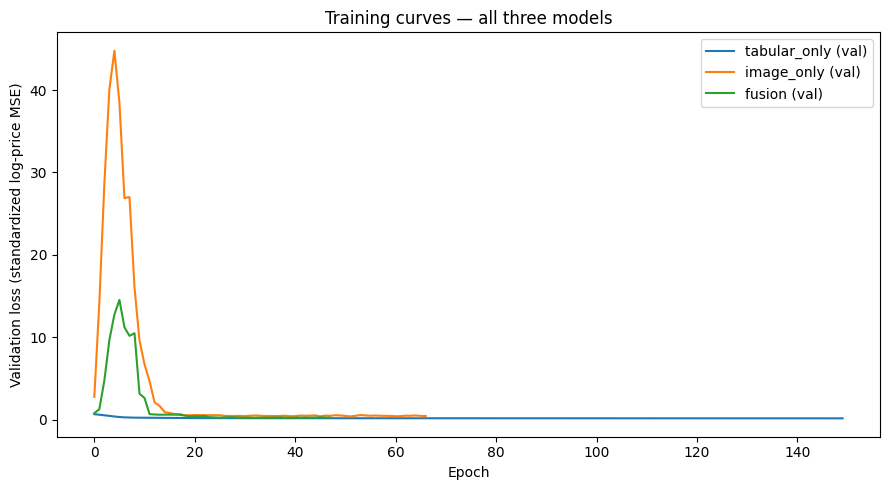

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, hist in histories.items():
    ax.plot(hist.history["val_loss"], label=f"{name} (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss (standardized log-price MSE)")
ax.set_title("Training curves — all three models")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "training_curves.png"), dpi=120)
plt.show()


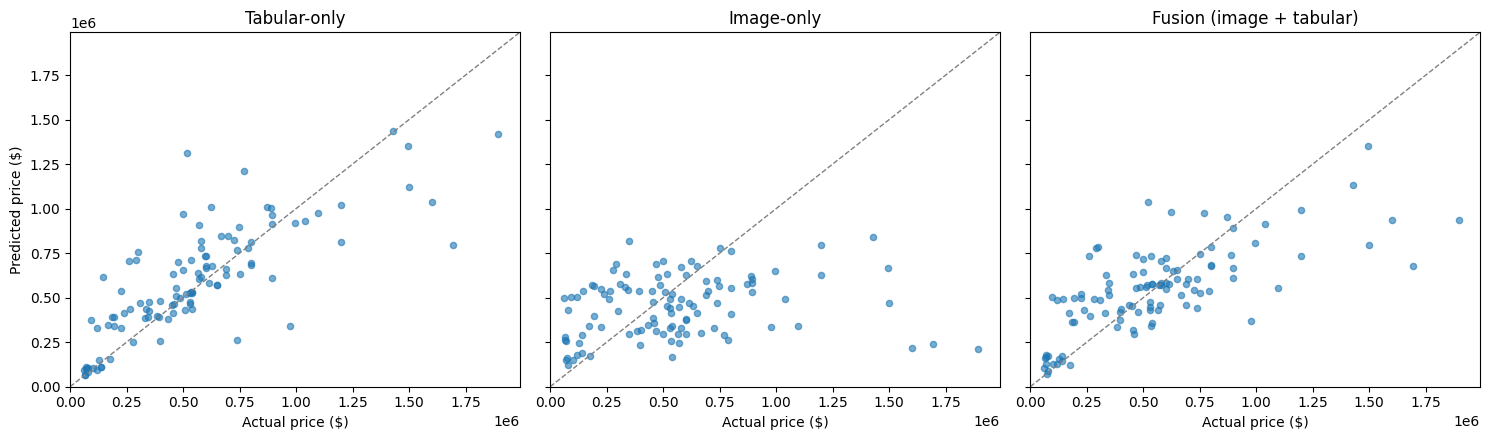

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
lims = [0, max(price_test.max(), max(p.max() for p in predictions.values())) * 1.05]

for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(price_test, preds, alpha=0.6, s=20)
    ax.plot(lims, lims, "--", color="gray", linewidth=1)  # perfect-prediction reference line
    ax.set_title(name)
    ax.set_xlabel("Actual price ($)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

axes[0].set_ylabel("Predicted price ($)")
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "predicted_vs_actual.png"), dpi=120)
plt.show()


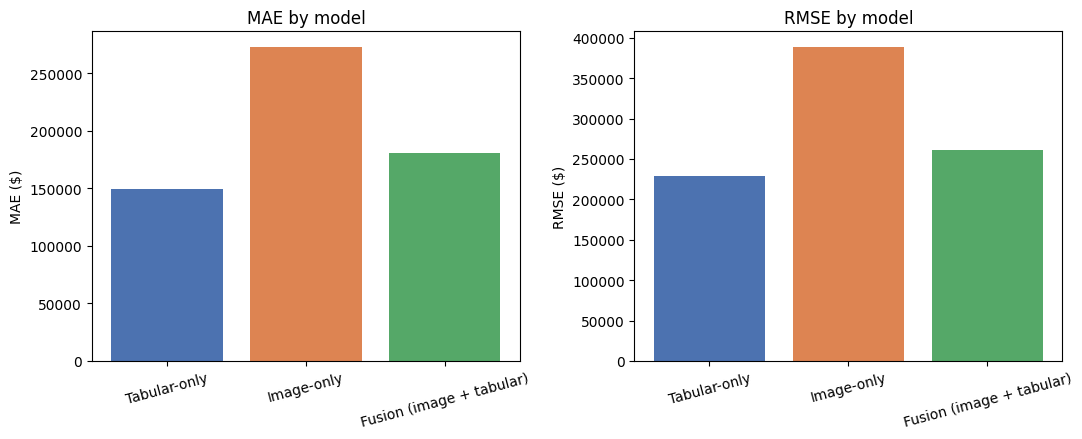

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
names = list(results.keys())
maes = [results[n][0] for n in names]
rmses = [results[n][1] for n in names]
colors = ["#4C72B0", "#DD8452", "#55A868"]

axes[0].bar(names, maes, color=colors)
axes[0].set_title("MAE by model")
axes[0].set_ylabel("MAE ($)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(names, rmses, color=colors)
axes[1].set_title("RMSE by model")
axes[1].set_ylabel("RMSE ($)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "model_comparison.png"), dpi=120)
plt.show()


## 8. Summary / Insights

**Results recap** (test set, 107 houses):

| Model | MAE | RMSE |
|---|---|---|
| Tabular-only | $149,683 | $228,619 |
| Image-only | $272,664 | $388,596 |
| Fusion (image + tabular) | $180,482 | $261,171 |

**What actually happened here, and why:**

- **Tabular data alone is doing most of the work, and does it well.** Square footage,
  bedroom/bathroom count, and zip code are strong, low-noise predictors of price, that's
  basically what a real estate appraiser looks at first, and it shows: the tabular-only MLP is
  the best model of the three.
- **The image-only model is clearly the weakest**, by a wide margin (MAE ~1.8x worse than
  tabular-only). Two reasons stand out: (1) 535 houses is a small dataset to train a CNN from
  scratch on, there just isn't enough data for the network to learn robust "expensive-looking
  house" features instead of memorizing noise, and (2) photos capture staging and photography
  quality as much as they capture the house itself, which adds variance that has nothing to do
  with price.
- **Fusion actually underperforms tabular-only here**, not by a rounding error, but
  noticeably (MAE ~$30K higher). That's a genuinely useful finding, not a failure to bury quietly.
  Concatenating a weak, noisy image-feature vector onto strong tabular features doesn't just fail
  to help; it can actively hurt, because the fusion network has to spend capacity learning to
  partially ignore the image branch rather than getting a clean signal from tabular features
  alone. Multimodal fusion is not automatically better than the best single modality, it's
  only better when *every* modality it's combining is pulling its weight, and here the image
  branch wasn't.

**What would likely close the gap:**
- **Transfer learning.** Swapping the from-scratch CNN for a pretrained backbone (ResNet50,
  MobileNetV2, etc. with frozen or fine-tuned ImageNet weights) would give the image branch a huge
  head start, since it wouldn't need to learn generic visual features from just 535 examples. This
  is the single biggest likely improvement and a natural next step for this project.
- **More/better images.** A single frontal shot plus interior room quality (finishes, lighting,
  clutter) captured more explicitly, rather than 4 low-res thumbnails tiled together, would give
  the CNN more informative signal.
- **A learned fusion weighting** (e.g. a gating layer) instead of naive concatenation, so the
  model can down-weight the image branch when it's not confident, rather than always trusting it
  equally with the tabular branch.

The honest takeaway: multimodal fusion is a real, useful technique, but it isn't magic, it's
only as good as its weakest input. With a small from-scratch CNN on 535 images, the image signal
here was weak enough that fusion made predictions slightly worse, not better. That's a more
useful thing to learn from this project than a fusion model that "wins" only because the write-up
doesn't run the single-modality baselines needed to notice it didn't.
